# 02 — Cell2location Abundances and NMF-Defined Tissue Niches

This notebook examines how cell2location-derived cell-abundance profiles organize into multicellular tissue niches in the processed human IPF Visium dataset.

The analysis uses precomputed results stored in the processed `AnnData` object. It does not rerun cell2location or NMF.

In [ ]:
import warnings

# tqdm emits this non-fatal warning when optional notebook widgets are unavailable.
warnings.filterwarnings(
    "ignore",
    message=r"IProgress not found.*",
    category=Warning,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="white")

## Load the processed dataset

The large `.h5ad` file is stored outside the Git repository. Update the path below if its location changes.

In [2]:
adata = sc.read_h5ad("../data/adata_vis_human_spatial_paper.h5ad")
adata

AnnData object with n_obs × n_vars = 57787 × 12486
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden_25', 'sampleID', 'treatment', 'VisiumSlides', 'technology', 'patient', 'AT0', 'AT1', 'AT2', 'Aberrant basaloid', 'Adventitial fibroblast', 'Alveolar fibroblast', 'Artery', 'B/Plasma', 'Basal', 'Basophil/Mast', 'Bronchial Vessel', 'Capillary', 'Capillary Aerocyte', 'Ciliated', 'Ciliated SFTPB+/SCGB1A1+', 'Dendritic', 'Ionocyte', 'Lymphatic', 'Macrophage C1Q hi', 'Macrophage CHI3L1+/CD9 hi/', 'Macrophage FABP4+', 'Macrophage IL1B+', 'Macrophage LYVE1+', 'Macrophage RETN+/VCAN+', 'Mesothelial', 'Monocyte', 'Mucous', 'Myofibroblast', 'NK', 'Peribronchial fibroblast', 'Pericyte', 'Smooth Muscle', 'T cell', 'TB-SC', 'Vein', 'pDC', 'preTB-SC/RAS', 'Androgen', 'EGFRsignaling', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'p53', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'mean_nUMI_fa

## Recover the cell2location abundance matrix

The conservative 5% posterior quantile (`q05_cell_abundance_w_sf`) is used as the primary cell-abundance estimate. Rows correspond to Visium spots and columns correspond to inferred lung cell populations.

In [3]:
cell_abundance = adata.obsm["q05_cell_abundance_w_sf"].copy()

if not isinstance(cell_abundance, pd.DataFrame):
    cell_abundance = pd.DataFrame(
        cell_abundance,
        index=adata.obs_names,
        columns=adata.uns["oncelltypes"],
    )


cell_abundance.columns = (
    cell_abundance.columns
    .str.replace(
        r"^q05cell_abundance_w_sf_",
        "",
        regex=True,
    )
)

print(f"Cell2location matrix: {cell_abundance.shape[0]:,} spots × {cell_abundance.shape[1]} cell populations")
cell_abundance.head()

Cell2location matrix: 57,787 spots × 37 cell populations


,AT0,AT1,AT2,Aberrant basaloid,Adventitial fibroblast,Alveolar fibroblast,Artery,B/Plasma,Basal,Basophil/Mast,...,Myofibroblast,NK,Peribronchial fibroblast,Pericyte,Smooth Muscle,T cell,TB-SC,Vein,pDC,preTB-SC/RAS
spot_id,,,,,,,,,,,,,,,,,,,,,
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1,0.001162,0.012275,0.000589,0.002108,0.203605,1.176494,0.027367,0.824555,0.265306,0.053716,...,0.003276,0.014663,0.043533,0.221838,0.147173,0.034529,0.001803,0.106638,0.008943,0.002292
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1,0.284728,0.797208,0.466162,0.047545,0.064358,0.038488,0.030167,0.072710,0.001503,0.004011,...,0.382100,0.137339,0.054350,0.763590,0.010048,0.034626,0.005220,0.010705,0.020047,0.002497
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1,0.006953,0.053596,0.013402,0.002963,0.061115,0.068147,0.065031,0.011949,0.001548,0.008882,...,0.587144,0.059556,0.016156,1.338197,0.083706,0.073377,0.001867,0.006160,0.004211,0.000564
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1,0.004011,0.052910,0.002612,0.035115,0.070470,0.676508,0.018409,0.302522,0.000960,0.181993,...,0.481221,0.030098,0.305133,0.034607,1.580754,0.189599,0.004437,0.026316,0.027901,0.007598
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1,0.008899,0.018407,0.027748,0.005379,0.097108,1.371261,0.057571,0.098303,0.002723,0.206517,...,0.024472,0.024034,0.277523,0.087687,0.235551,0.056909,0.006370,0.043812,0.021519,0.008398


In [4]:
cell_types = cell_abundance.columns.tolist()
cell_types

['AT0',
 'AT1',
 'AT2',
 'Aberrant basaloid',
 'Adventitial fibroblast',
 'Alveolar fibroblast',
 'Artery',
 'B/Plasma',
 'Basal',
 'Basophil/Mast',
 'Bronchial Vessel',
 'Capillary',
 'Capillary Aerocyte',
 'Ciliated',
 'Ciliated SFTPB+/SCGB1A1+',
 'Dendritic',
 'Ionocyte',
 'Lymphatic',
 'Macrophage C1Q hi',
 'Macrophage CHI3L1+/CD9 hi/',
 'Macrophage FABP4+',
 'Macrophage IL1B+',
 'Macrophage LYVE1+',
 'Macrophage RETN+/VCAN+',
 'Mesothelial',
 'Monocyte',
 'Mucous',
 'Myofibroblast',
 'NK',
 'Peribronchial fibroblast',
 'Pericyte',
 'Smooth Muscle',
 'T cell',
 'TB-SC',
 'Vein',
 'pDC',
 'preTB-SC/RAS']

## NMF-defined tissue niches

`Niche_NMF` assigns each spot to one of eight multicellular tissue environments derived from the cell-abundance profiles.

In [5]:
niche_counts = adata.obs["Niche_NMF"].value_counts()
niche_percent = 100 * niche_counts / niche_counts.sum()

niche_summary = pd.DataFrame({
    "spots": niche_counts,
    "percent": niche_percent.round(2),
})
niche_summary

,spots,percent
Niche_NMF,,
Alveolar,31496,54.50
SMCs_Adv_Meso,7561,13.08
Fibroblast,5521,9.55
Immune,5445,9.42
Airway,3161,5.47
Fibrotic,2830,4.90
Macrophage_SPP1,913,1.58
Macrophage_FABP4,860,1.49


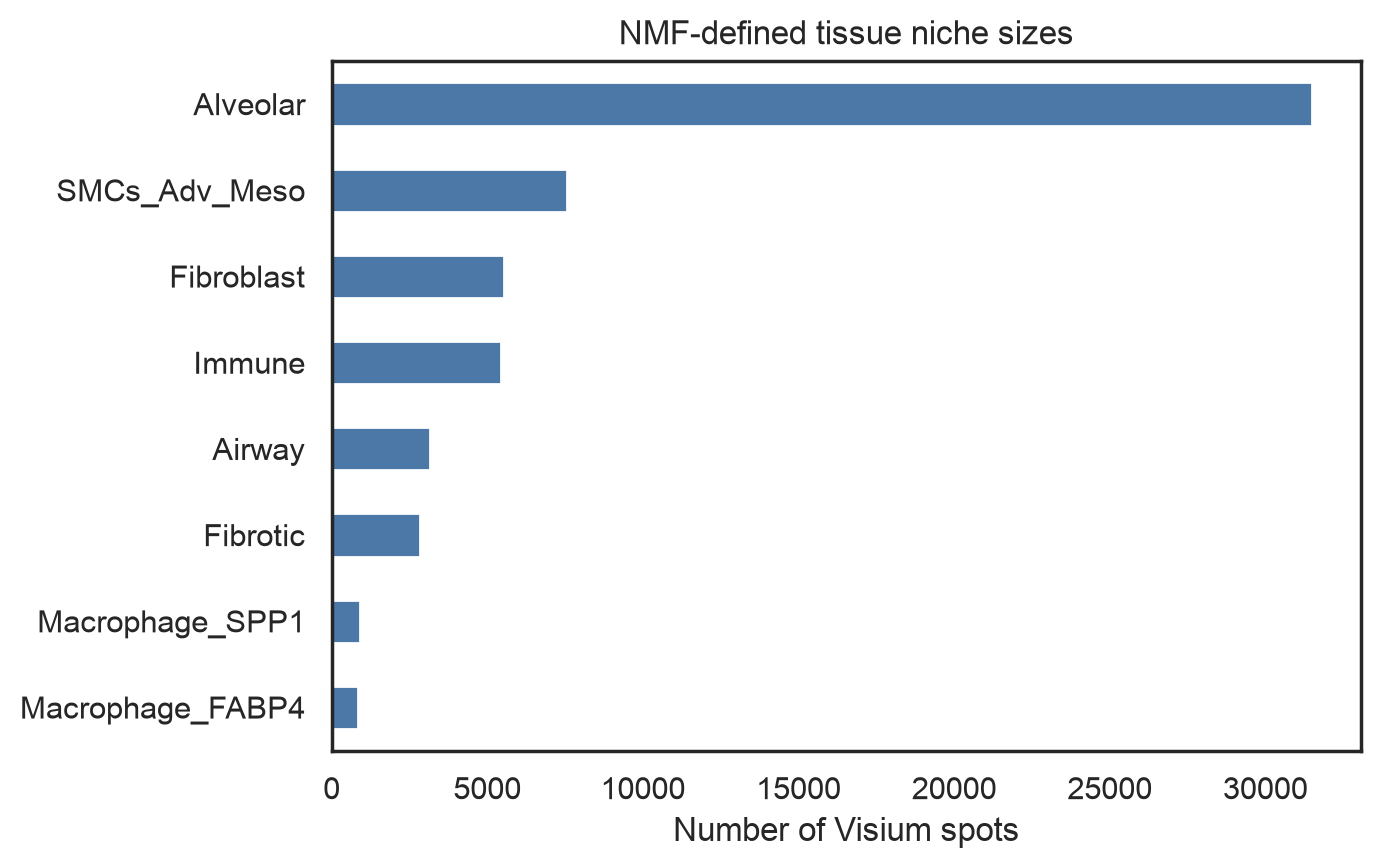

In [6]:
ax = niche_counts.sort_values().plot.barh(
    figsize=(7, 4.5),
    color="#4C78A8",
)
ax.set_xlabel("Number of Visium spots")
ax.set_ylabel("")
ax.set_title("NMF-defined tissue niche sizes")
plt.tight_layout()

## Cell-population composition of each niche

Mean cell2location abundance is calculated within each niche. Values are then standardized separately for each cell population so that the heatmap emphasizes relative enrichment across niches rather than differences in absolute abundance scale.

In [7]:
abundance_with_niche = cell_abundance.copy()
abundance_with_niche["Niche_NMF"] = adata.obs["Niche_NMF"].to_numpy()

niche_mean_abundance = abundance_with_niche.groupby(
    "Niche_NMF",
    observed=True,
).mean()

niche_abundance_z = niche_mean_abundance.apply(
    lambda values: (values - values.mean()) / values.std(ddof=0),
    axis=0,
).fillna(0)

niche_mean_abundance.shape

(8, 37)

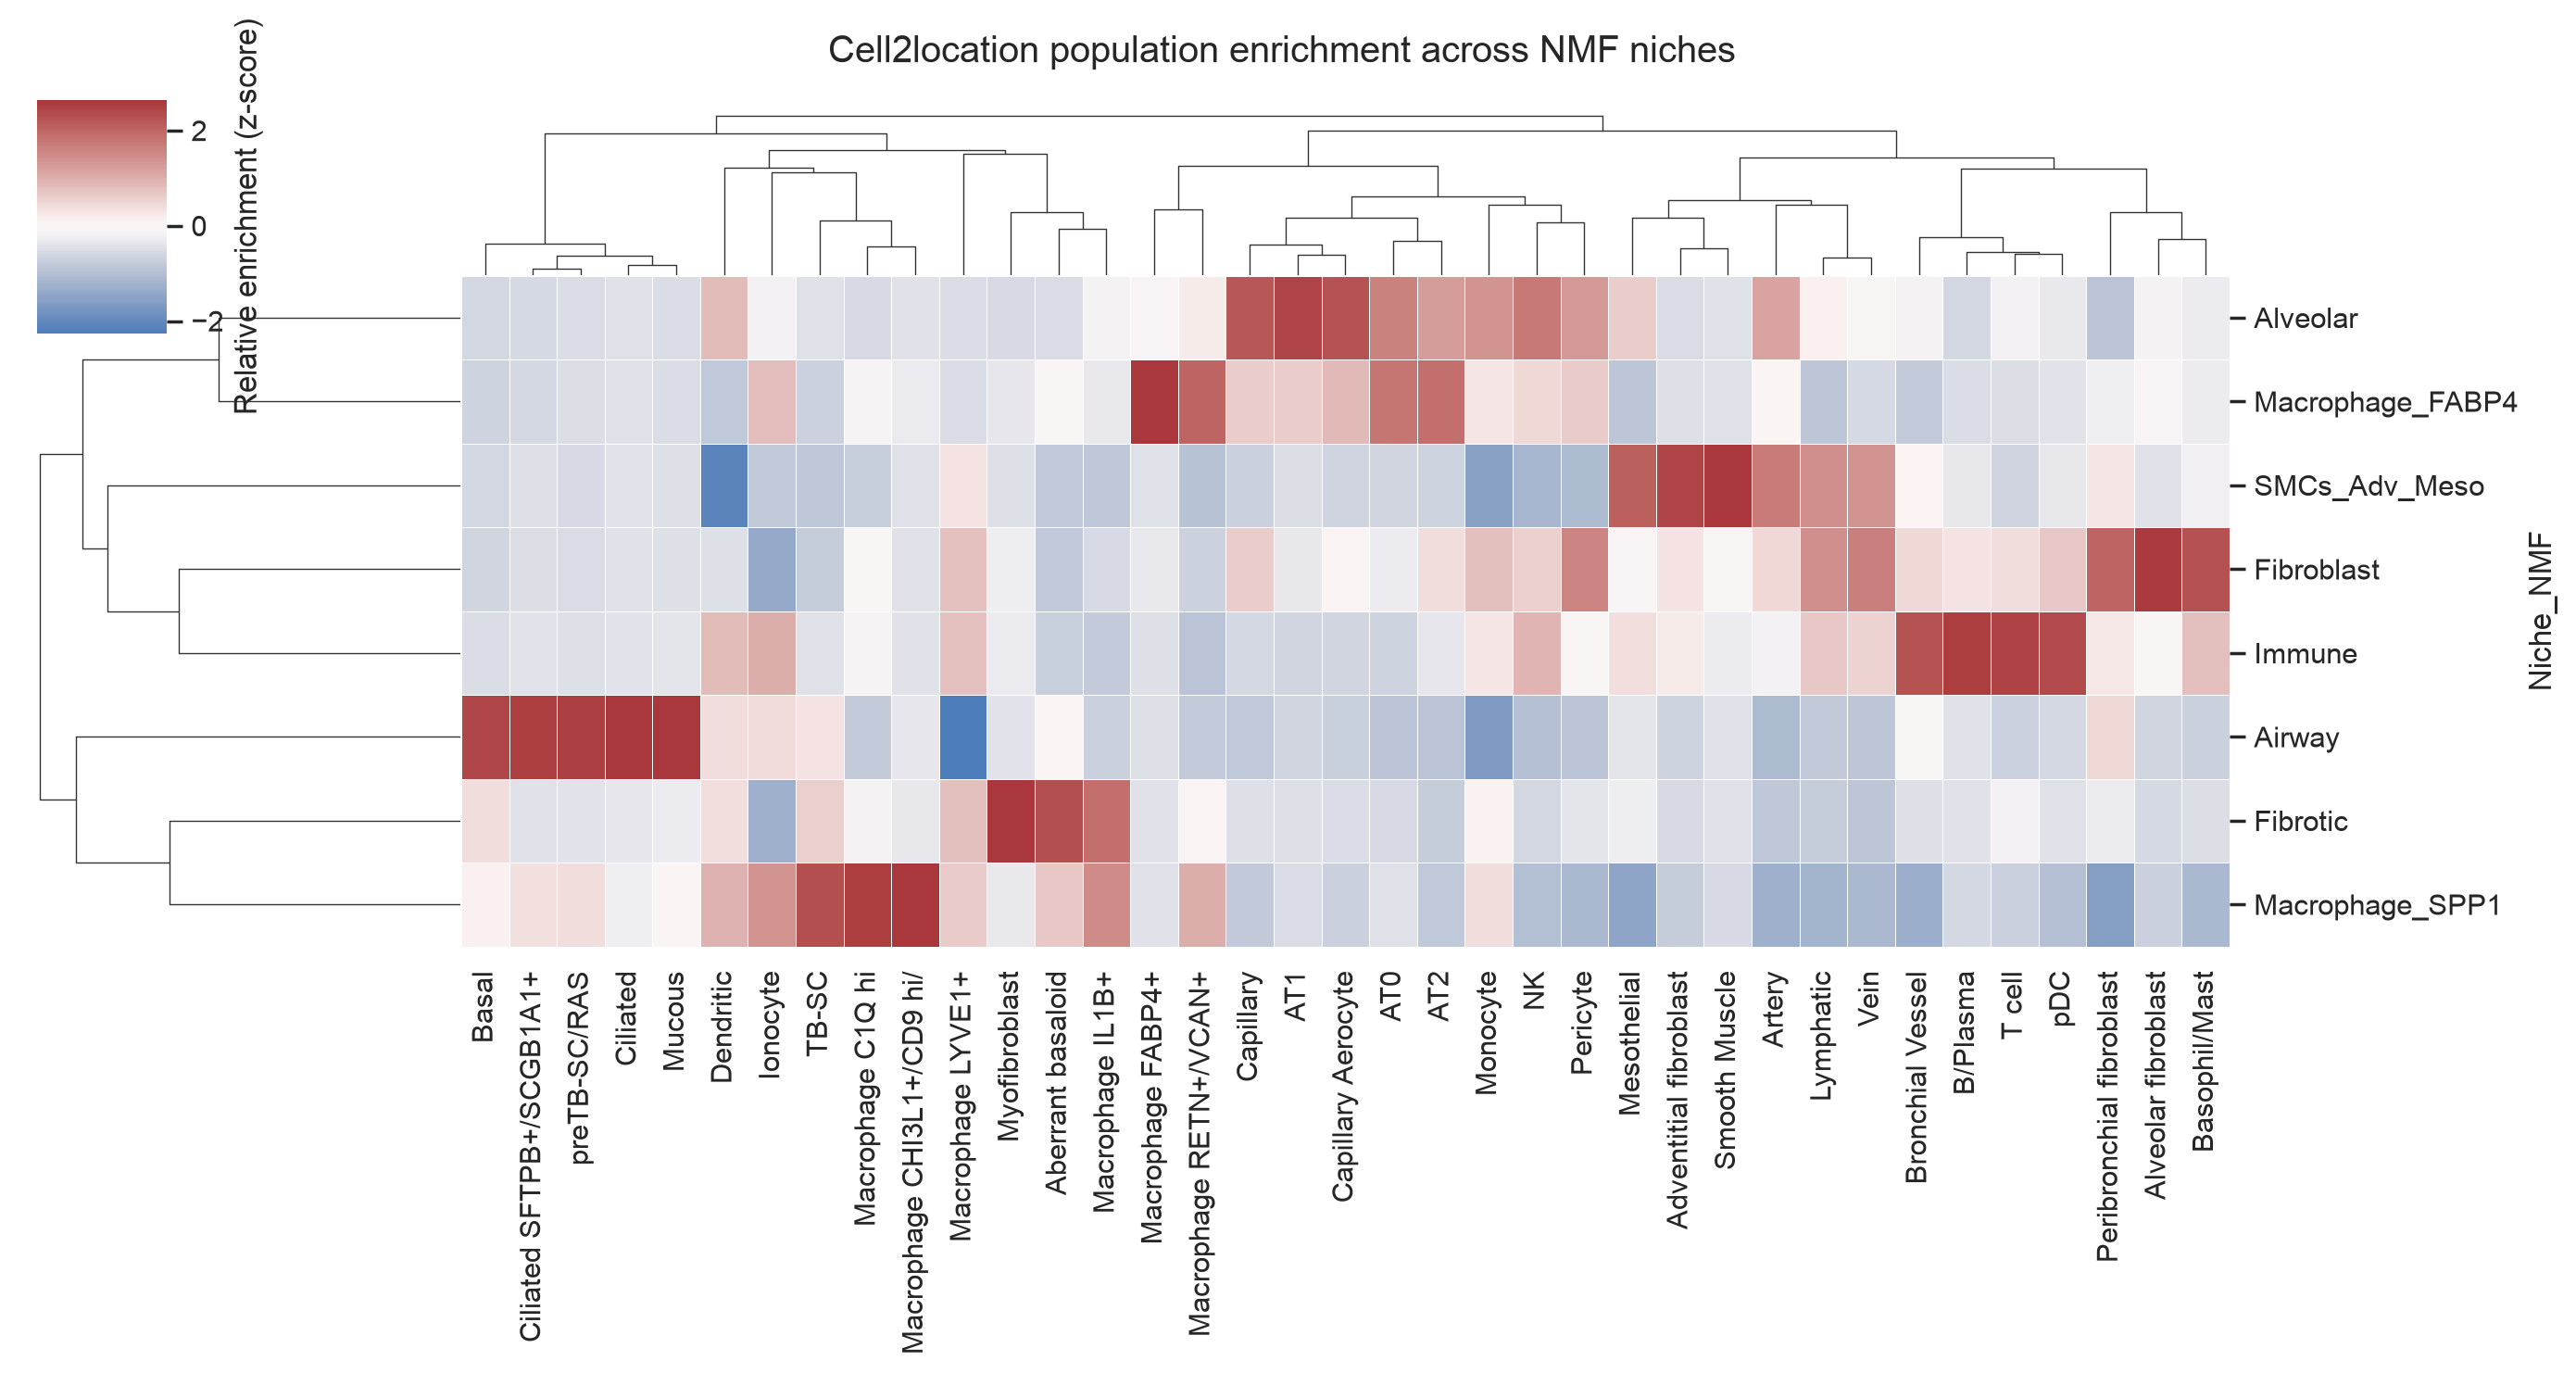

In [8]:
sns.clustermap(
    niche_abundance_z,
    cmap="vlag",
    center=0,
    figsize=(14, 7),
    linewidths=0.2,
    cbar_kws={"label": "Relative enrichment (z-score)"},
)
plt.suptitle(
    "Cell2location population enrichment across NMF niches",
    y=1.03,
)
plt.show()

## Highest-abundance populations per niche

The table below lists the five populations with the largest mean cell2location abundance in each niche. These values help assign biological meaning to the NMF-derived labels.

In [9]:
top_cell_types = {}

for niche, values in niche_mean_abundance.iterrows():
    top_cell_types[niche] = values.nlargest(5).index.tolist()

top_cell_types_table = pd.DataFrame(top_cell_types).T
top_cell_types_table.columns = [f"rank_{rank}" for rank in range(1, 6)]
top_cell_types_table

,rank_1,rank_2,rank_3,rank_4,rank_5
Airway,Ciliated,Mucous,Basal,preTB-SC/RAS,Ciliated SFTPB+/SCGB1A1+
Alveolar,AT1,Macrophage FABP4+,Capillary Aerocyte,Capillary,Pericyte
Fibroblast,Alveolar fibroblast,B/Plasma,Smooth Muscle,Pericyte,T cell
Fibrotic,Myofibroblast,Aberrant basaloid,Basal,T cell,B/Plasma
Immune,B/Plasma,T cell,Alveolar fibroblast,Bronchial Vessel,Smooth Muscle
Macrophage_FABP4,Macrophage FABP4+,AT2,Alveolar fibroblast,AT1,AT0
Macrophage_SPP1,Macrophage CHI3L1+/CD9 hi/,Macrophage C1Q hi,TB-SC,Aberrant basaloid,Mucous
SMCs_Adv_Meso,Smooth Muscle,Adventitial fibroblast,Artery,B/Plasma,Vein


## NMF factor profiles across niches

The processed object contains ten continuous NMF factor scores. Their mean values across the discrete niche assignments provide a direct link between the underlying factors and the final niche labels.

In [10]:
nmf_factors = [
    column for column in adata.obs.columns
    if column.startswith("mean_nUMI_factorsfact_")
]

nmf_by_niche = adata.obs.groupby(
    "Niche_NMF",
    observed=True,
)[nmf_factors].mean()

nmf_by_niche.columns = [f"factor_{index}" for index in range(len(nmf_factors))]
nmf_by_niche

,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9
Niche_NMF,,,,,,,,,,
Airway,0.149367,0.114250,0.010301,0.091717,0.086330,3.616545,0.178602,0.190973,0.001742,0.047779
Alveolar,0.096844,3.001073,0.249103,0.278649,0.012510,0.006638,0.061940,0.087841,0.019992,0.127779
Fibroblast,0.434183,0.571004,0.119563,2.656069,0.009385,0.029714,0.179245,0.606958,0.021026,1.731875
Fibrotic,0.148549,0.309806,0.065698,0.138750,0.109031,0.135333,2.092128,0.220726,0.004389,0.069017
Immune,0.280446,0.320683,0.009193,0.519732,0.024335,0.052834,0.160971,2.150958,0.012613,0.265893
Macrophage_FABP4,0.124442,1.521555,3.217492,0.427764,0.132398,0.009691,0.174142,0.127053,0.014711,0.194025
Macrophage_SPP1,0.025877,0.206527,0.070119,0.040208,3.752773,0.273466,0.224965,0.101422,0.000396,0.012373
SMCs_Adv_Meso,3.168810,0.229804,0.019634,0.242130,0.006229,0.041576,0.078584,0.247040,0.091563,0.144966


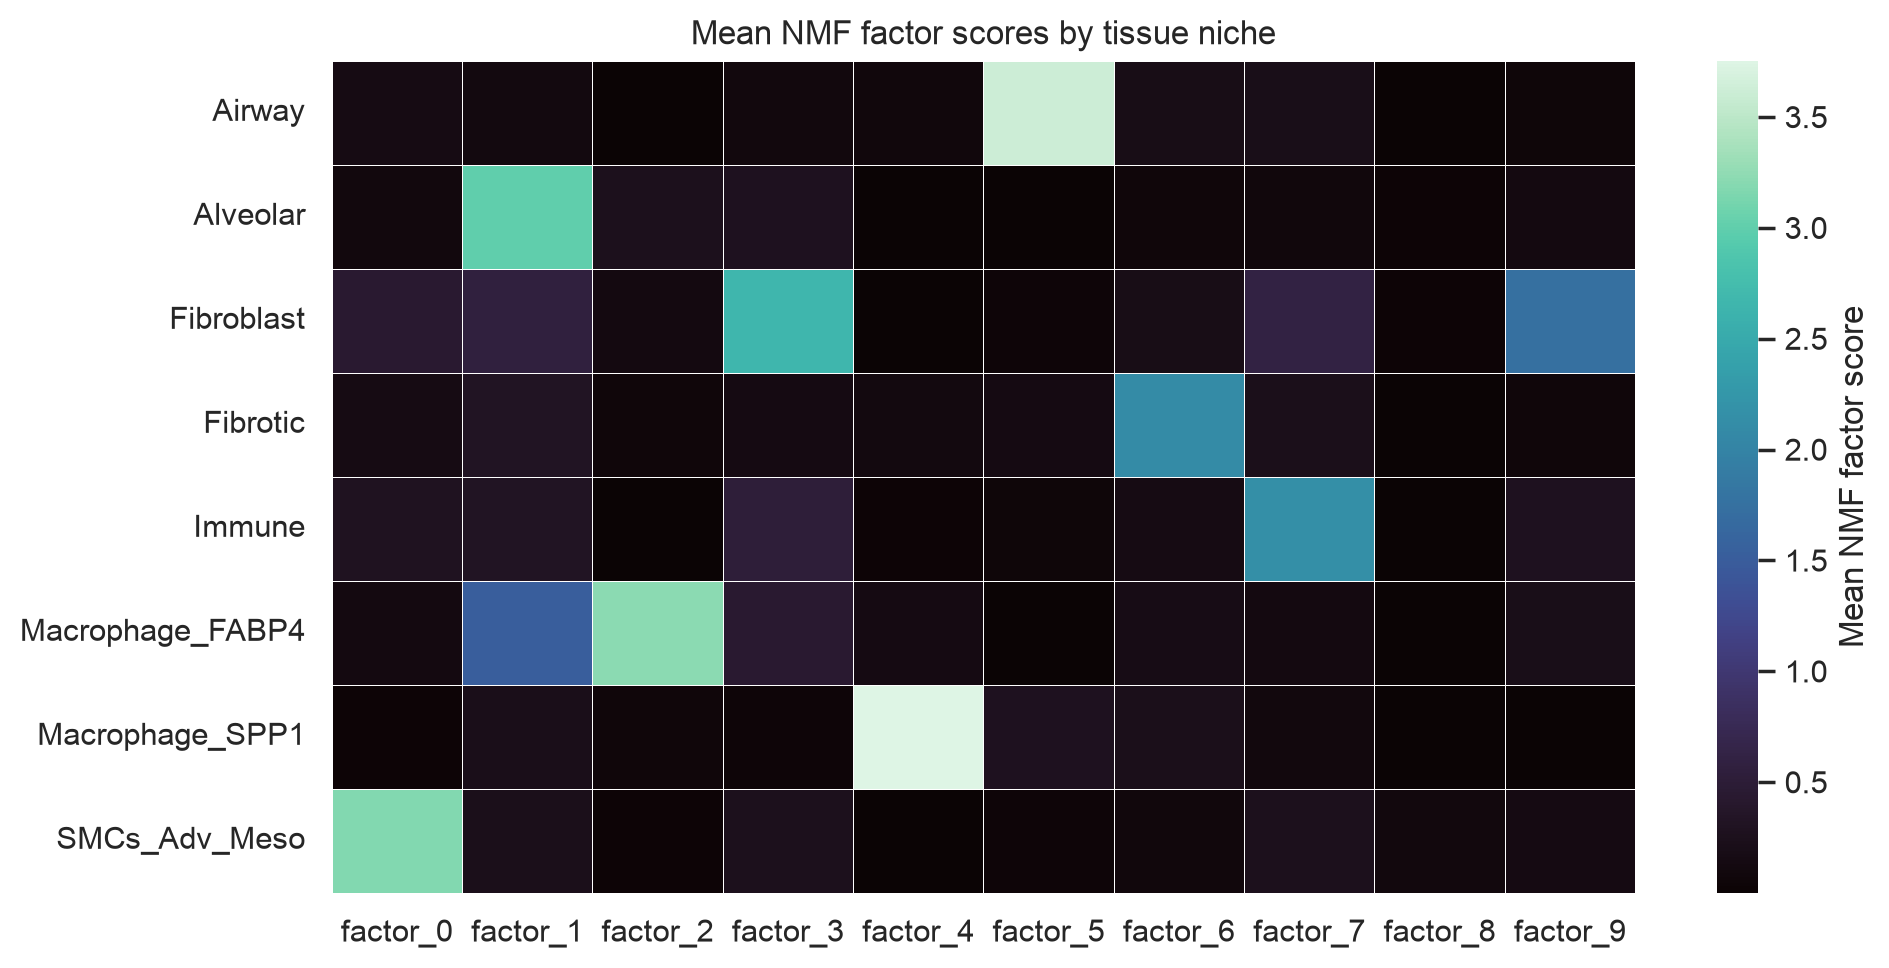

In [11]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    nmf_by_niche,
    cmap="mako",
    linewidths=0.3,
    cbar_kws={"label": "Mean NMF factor score"},
)
plt.title("Mean NMF factor scores by tissue niche")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

### Reconstructed cell-type loadings for the original NMF factors

The processed object retains the ten original spot-level NMF factor scores in `adata.obs`, but it does not retain the original `factor × cell type` loading matrix. To visualize cell-type composition for those original factors, the original spot-factor score matrix is held fixed and non-negative least squares is used to find the cell-type loadings that best reconstruct the stored cell2location abundance matrix.

These are **reconstructed loadings compatible with the stored original factor scores**, not the exact loadings from the original NMF fit.

In [12]:
from scipy.optimize import nnls

original_factor_columns = sorted(
    [
        column for column in adata.obs.columns
        if column.startswith("mean_nUMI_factorsfact_")
    ],
    key=lambda column: int(column.rsplit("_", 1)[-1]),
)

W_original = adata.obs[original_factor_columns].to_numpy(dtype=float)
X_original = cell_abundance.to_numpy(dtype=float)

# Solve X[:, cell_type] ≈ W_original @ loading[:, cell_type]
# independently for every cell population under a non-negativity constraint.
H_original_reconstructed = np.column_stack([
    nnls(W_original, X_original[:, cell_index])[0]
    for cell_index in range(X_original.shape[1])
])

original_factor_names = [
    f"Original_Factor_{index}"
    for index in range(len(original_factor_columns))
]

original_factor_cell_loadings = pd.DataFrame(
    H_original_reconstructed,
    index=original_factor_names,
    columns=cell_abundance.columns,
)

original_reconstruction = W_original @ H_original_reconstructed
relative_reconstruction_error = (
    np.linalg.norm(X_original - original_reconstruction)
    / np.linalg.norm(X_original)
)

print(f"Original W (spot × factor): {W_original.shape}")
print(f"Reconstructed H (factor × cell type): {original_factor_cell_loadings.shape}")
print(f"Relative reconstruction error: {relative_reconstruction_error:.4f}")

original_factor_cell_loadings

Original W (spot × factor): (57787, 10)
Reconstructed H (factor × cell type): (10, 37)
Relative reconstruction error: 0.4132


,AT0,AT1,AT2,Aberrant basaloid,Adventitial fibroblast,Alveolar fibroblast,Artery,B/Plasma,Basal,Basophil/Mast,...,Myofibroblast,NK,Peribronchial fibroblast,Pericyte,Smooth Muscle,T cell,TB-SC,Vein,pDC,preTB-SC/RAS
Original_Factor_0,0.004902,0.000703,0.000621,0.001442,0.112992,0.005363,0.009486,0.006874,0.001636,0.008606,...,0.006973,0.003054,0.015891,0.000000,0.819185,0.003723,0.002190,0.036839,0.005914,0.002997
Original_Factor_1,0.066769,0.224847,0.075487,0.011870,0.004724,0.043273,0.037282,0.005965,0.004314,0.010915,...,0.003240,0.038440,0.008440,0.087746,0.007670,0.045670,0.010854,0.017559,0.009237,0.005459
Original_Factor_2,0.043284,0.000000,0.062978,0.017415,0.000000,0.010355,0.000687,0.007631,0.000000,0.002490,...,0.000000,0.001823,0.007678,0.028356,0.001707,0.000000,0.000000,0.000000,0.002210,0.002090
Original_Factor_3,0.000000,0.000000,0.058253,0.000000,0.031061,0.340262,0.015007,0.000000,0.000000,0.011261,...,0.020349,0.013560,0.041371,0.129043,0.000000,0.033897,0.000000,0.000000,0.004631,0.001922
Original_Factor_4,0.009280,0.000000,0.000000,0.022039,0.000936,0.001330,0.000381,0.003852,0.011337,0.001526,...,0.000827,0.004078,0.000000,0.000052,0.001624,0.006273,0.027371,0.000445,0.002524,0.011050
Original_Factor_5,0.000000,0.000000,0.000000,0.016786,0.000000,0.003598,0.002538,0.007269,0.129582,0.004018,...,0.000000,0.006073,0.015350,0.005448,0.005885,0.004653,0.010379,0.002152,0.004336,0.057714
Original_Factor_6,0.030987,0.000000,0.000000,0.190726,0.004438,0.001158,0.003625,0.001993,0.091122,0.010899,...,0.749804,0.012095,0.030883,0.049813,0.008054,0.055244,0.041108,0.000000,0.008678,0.004328
Original_Factor_7,0.006504,0.000000,0.009402,0.000000,0.035538,0.021098,0.012755,0.576380,0.004069,0.027867,...,0.015556,0.031747,0.020366,0.017043,0.007406,0.254453,0.009980,0.036481,0.033467,0.004498
Original_Factor_8,0.000000,0.000000,0.000000,0.004786,0.000000,0.009699,1.424559,0.016226,0.000000,0.004343,...,0.000000,0.020145,0.000000,0.056140,0.033921,0.016953,0.000000,0.000000,0.007595,0.000000
Original_Factor_9,0.000000,0.000000,0.000000,0.000000,0.000000,0.306917,0.000000,0.030963,0.000000,0.051802,...,0.000000,0.000000,0.000000,0.000000,0.016415,0.000000,0.000000,0.073269,0.007650,0.000000


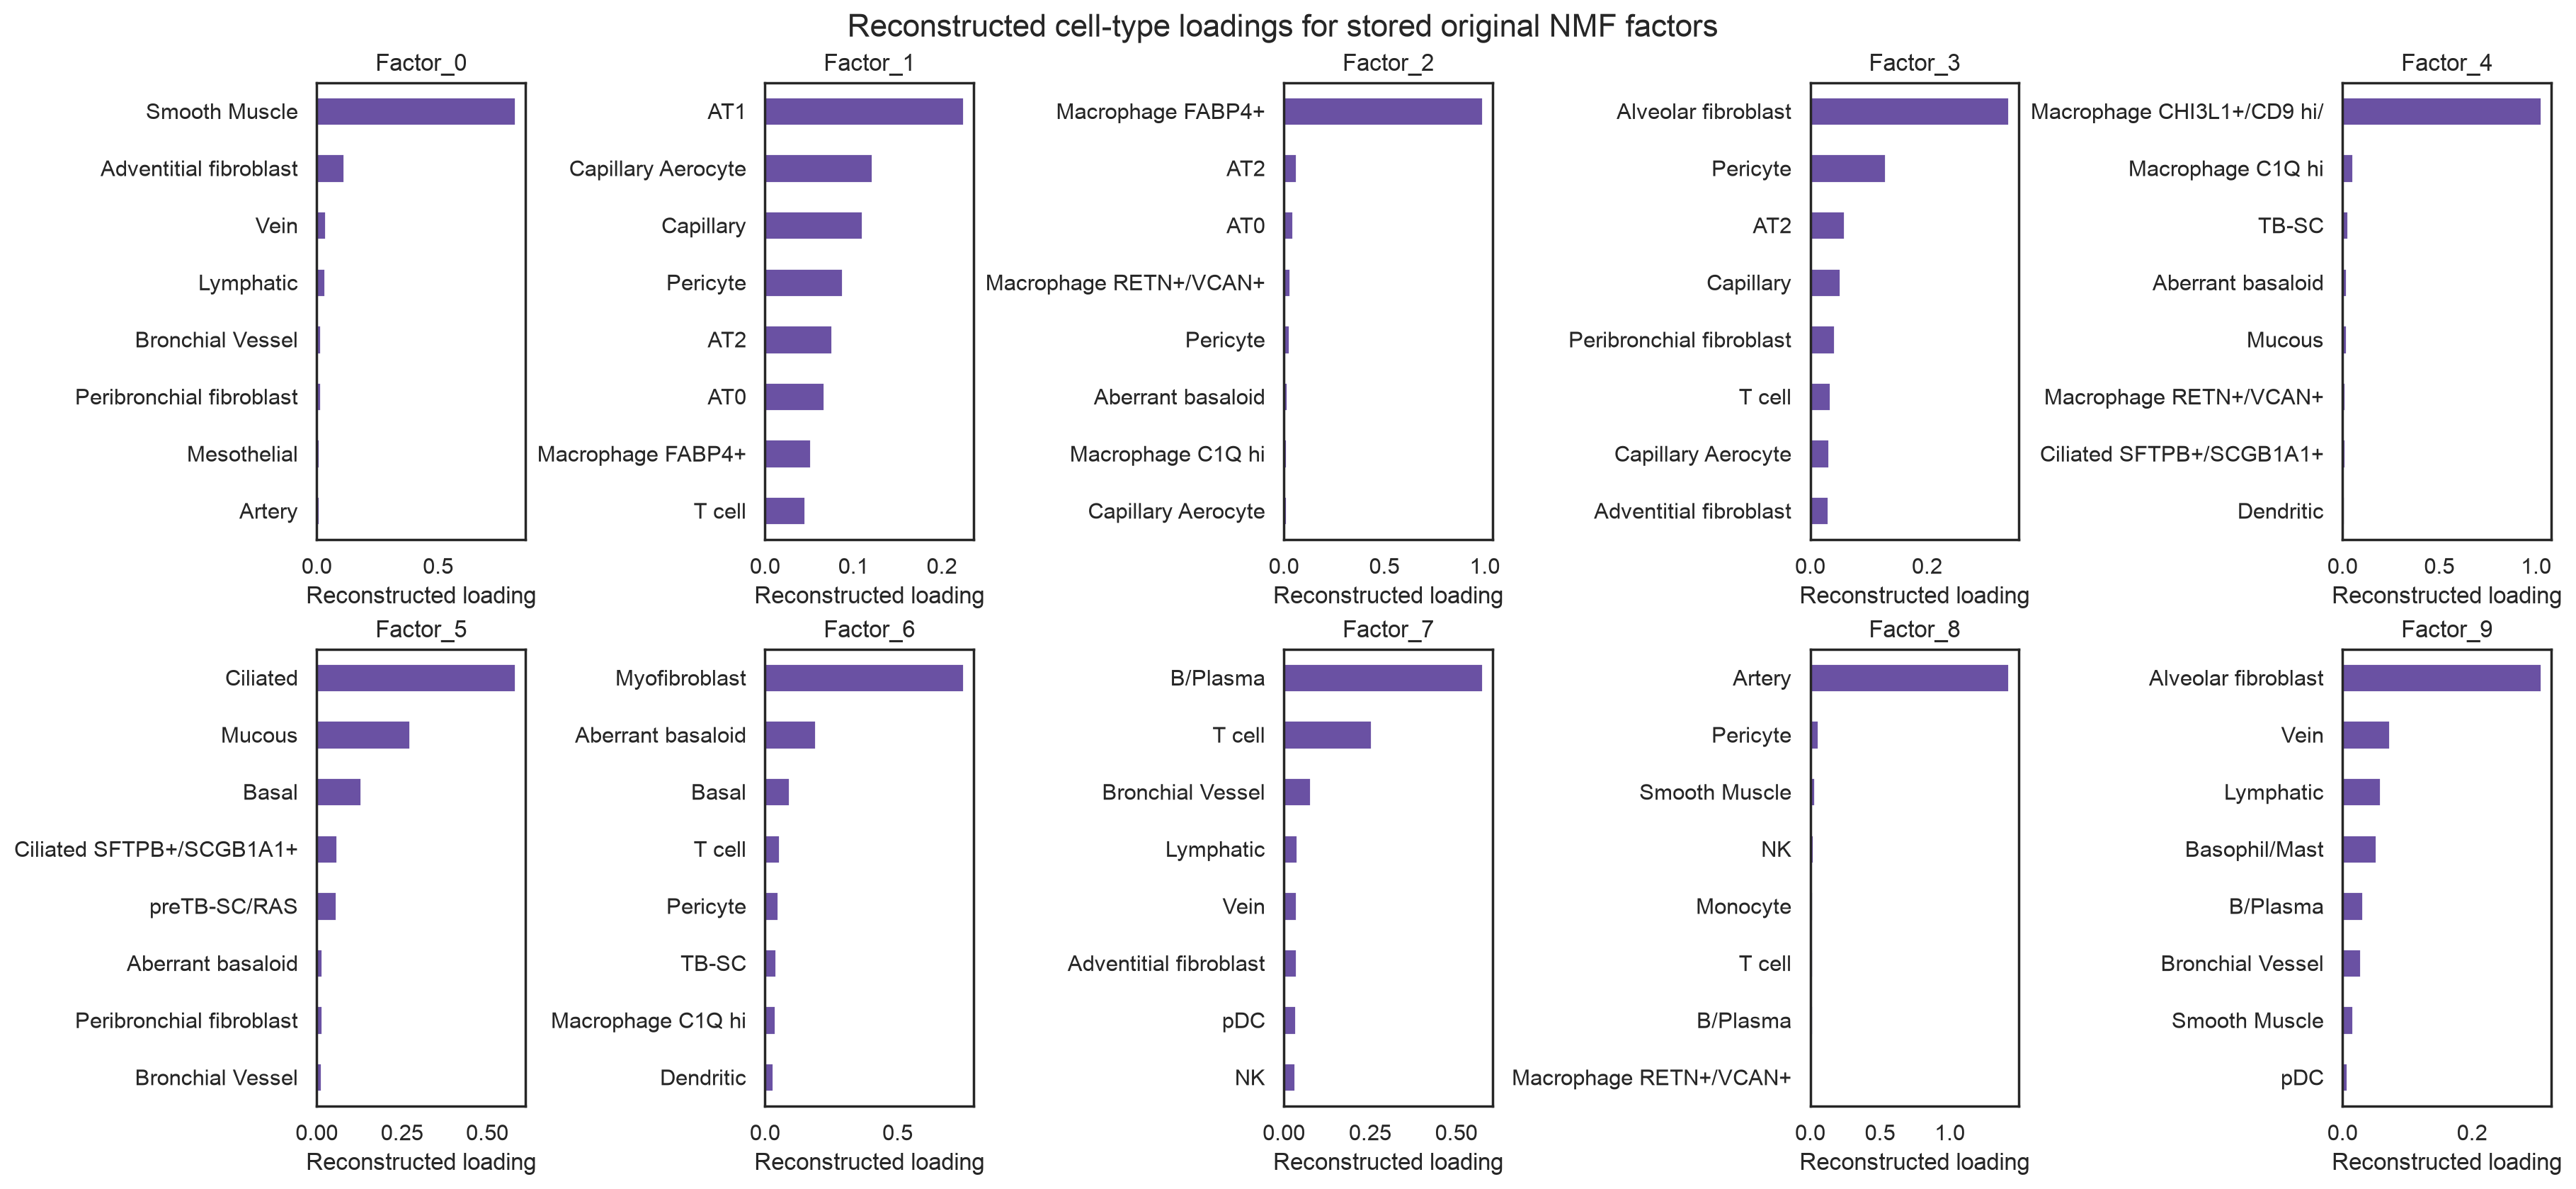

In [13]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8),
    constrained_layout=True,
)

for factor, ax in zip(original_factor_names, axes.flat):
    top_loadings = (
        original_factor_cell_loadings.loc[factor]
        .nlargest(8)
        .sort_values()
    )

    top_loadings.plot.barh(ax=ax, color="#6A51A3")
    ax.set_title(factor.replace("Original_", ""))
    ax.set_xlabel("Reconstructed loading")
    ax.set_ylabel("")

fig.suptitle(
    "Reconstructed cell-type loadings for stored original NMF factors",
    fontsize=16,
    y=1.03,
)
plt.show()

Factor 6 is fibrotic niche corresonding factor based on high myofibroblast and aberrant basaoloid cell population enrichment.

## Inspect a representative IPF section

The section containing the largest number of fibrotic-niche spots is selected automatically. This avoids hard-coding a sample and makes the notebook more robust to future dataset updates.

In [14]:
sample = "90_A1_H237762_IPF_processed_CM"

adata_sample = adata[adata.obs["sample"] == sample].copy()

print(f"Selected sample: {sample}")
print(f"Total spots: {adata_sample.n_obs:,}")
print(f"Fibrotic-niche spots: {(adata_sample.obs['Niche_NMF'] == 'Fibrotic').sum():,}")
print("Spatial library IDs:", list(adata_sample.uns.get("spatial", {}).keys()))

Selected sample: 90_A1_H237762_IPF_processed_CM
Total spots: 2,793
Fibrotic-niche spots: 161
Spatial library IDs: ['1217_0001_processed_aligned', '1217_0002_processed_aligned', '1217_0003_processed_aligned', '1217_0004_processed_aligned', '90_A1_H237762_IPF_processed_CM', '90_C1_RO-730_Healthy_processed_CM', '91_A1_RO-727_Healthy_processed_CM', '91_B1_RO-728_Healthy_processed_CM', '91_D1_24513-17_IPF_processed_CM', '92_A1_RO-3203_Healthy_processed_CM', '92_D1_RO-3736_IPF_processed_CM']


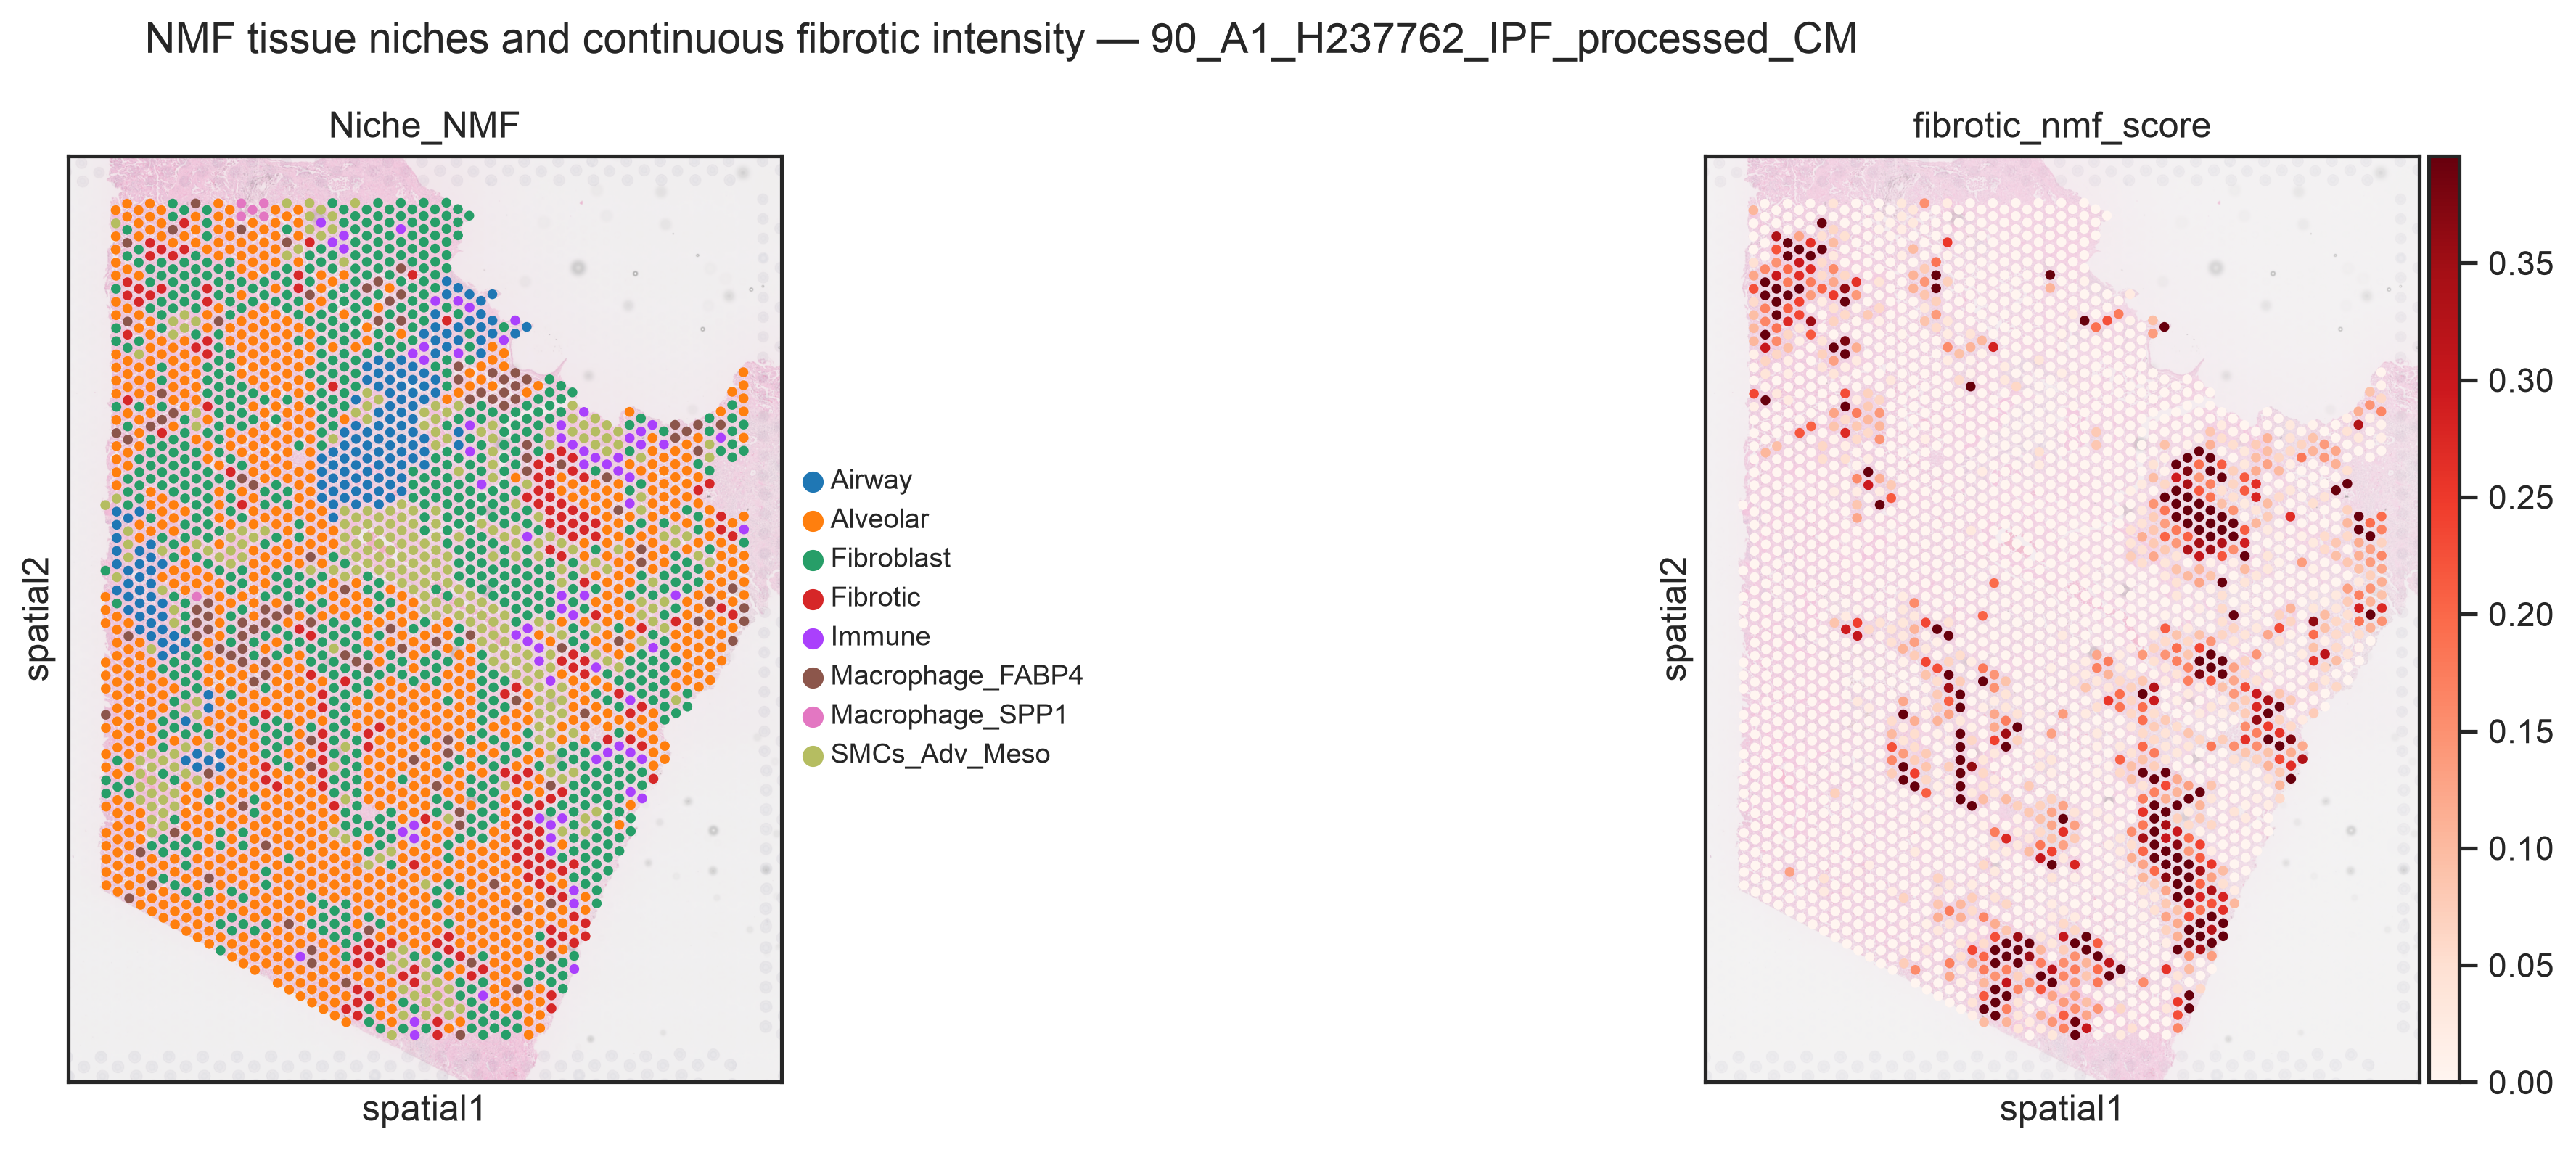

In [15]:
factor_columns = sorted(
    [
        column for column in adata_sample.obs.columns
        if column.startswith("mean_nUMI_factorsfact_")
    ],
    key=lambda column: int(column.rsplit("_", 1)[-1]),
)

# Factor 6 is the continuous factor most strongly associated with Fibrotic spots.
factor_total = adata_sample.obs[factor_columns].sum(axis=1).replace(0, np.nan)
adata_sample.obs["fibrotic_nmf_score"] = (
    adata_sample.obs["mean_nUMI_factorsfact_6"] / factor_total
).fillna(0)

# Clip only the color scale, not the underlying values, to reveal spatial contrast.
fibrotic_vmax = adata_sample.obs["fibrotic_nmf_score"].quantile(0.95)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.6),
    dpi=150,
    gridspec_kw={"wspace": 0.72},
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The function spatial is deprecated.*",
        category=FutureWarning,
    )

    sc.pl.spatial(
        adata_sample,
        color="Niche_NMF",
        library_id=sample,
        size=1.15,
        alpha_img=0.55,
        title="Niche_NMF",
        legend_loc="right margin",
        legend_fontsize=9,
        frameon=True,
        ax=axes[0],
        show=False,
    )

    sc.pl.spatial(
        adata_sample,
        color="fibrotic_nmf_score",
        library_id=sample,
        size=1.15,
        alpha_img=0.45,
        cmap="Reds",
        vmin=0,
        vmax=fibrotic_vmax,
        title="fibrotic_nmf_score",
        frameon=True,
        ax=axes[1],
        show=False,
    )

for ax in axes:
    ax.set_xlabel("spatial1")
    ax.set_ylabel("spatial2")

fig.suptitle(
    f"NMF tissue niches and continuous fibrotic intensity — {sample}",
    fontsize=14,
    y=1.02,
)

plt.show()

# Optional publication-quality export:
# fig.savefig("../figures/02_niches_and_fibrotic_score.png", dpi=300, bbox_inches="tight")

## Representative cell2location abundance maps

Spatial maps for selected stromal, epithelial, and macrophage populations provide a visual check that the inferred cell populations occupy biologically coherent regions.

In [16]:
representative_cell_types = sorted([
    "AT1",
    "AT2",
    "Aberrant basaloid",
    "Alveolar fibroblast",
    "B/Plasma",
    "Basal",
    "Macrophage C1Q hi",
    "Macrophage CHI3L1+/CD9 hi/",
    "Macrophage FABP4+",
    "Myofibroblast",
    "Smooth Muscle",
    "T cell",
])

representative_cell_types = [
    cell_type for cell_type in representative_cell_types
    if cell_type in adata_sample.obs.columns
]
representative_cell_types

['AT1',
 'AT2',
 'Aberrant basaloid',
 'Alveolar fibroblast',
 'B/Plasma',
 'Basal',
 'Macrophage C1Q hi',
 'Macrophage CHI3L1+/CD9 hi/',
 'Macrophage FABP4+',
 'Myofibroblast',
 'Smooth Muscle',
 'T cell']

In [ ]:
from matplotlib.colors import PowerNorm

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10),
    dpi=100,
    constrained_layout=True,
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The function spatial is deprecated.*",
        category=FutureWarning,
    )

    for cell_type, ax in zip(representative_cell_types, axes.flat):
        values = adata_sample.obs[cell_type]
        upper = values.quantile(0.98)
        upper = max(float(upper), np.finfo(float).eps)

        sc.pl.spatial(
            adata_sample,
            color=cell_type,
            library_id=sample,
            size=1.35,
            alpha_img=0.32,
            bw=True,
            cmap="viridis",
            norm=PowerNorm(gamma=0.5, vmin=0, vmax=upper),
            title=cell_type,
            frameon=True,
            colorbar_loc="right",
            ax=ax,
            show=False,
        )

        ax.set_xlabel("spatial1")
        ax.set_ylabel("spatial2")

for ax in axes.flat[len(representative_cell_types):]:
    ax.set_visible(False)

fig.suptitle(
    f"Cell2location abundance maps — {sample}",
    fontsize=16,
    y=1.02,
)

plt.show()

# Optional publication-quality export:
# fig.savefig("../figures/02_cell2location_abundance_maps.png", dpi=300, bbox_inches="tight")

## Fibrotic niche versus other tissue environments

The following comparison summarizes whether representative cell populations are elevated in spots assigned to the fibrotic niche. This is descriptive; formal spatial modeling is deferred to later notebooks.

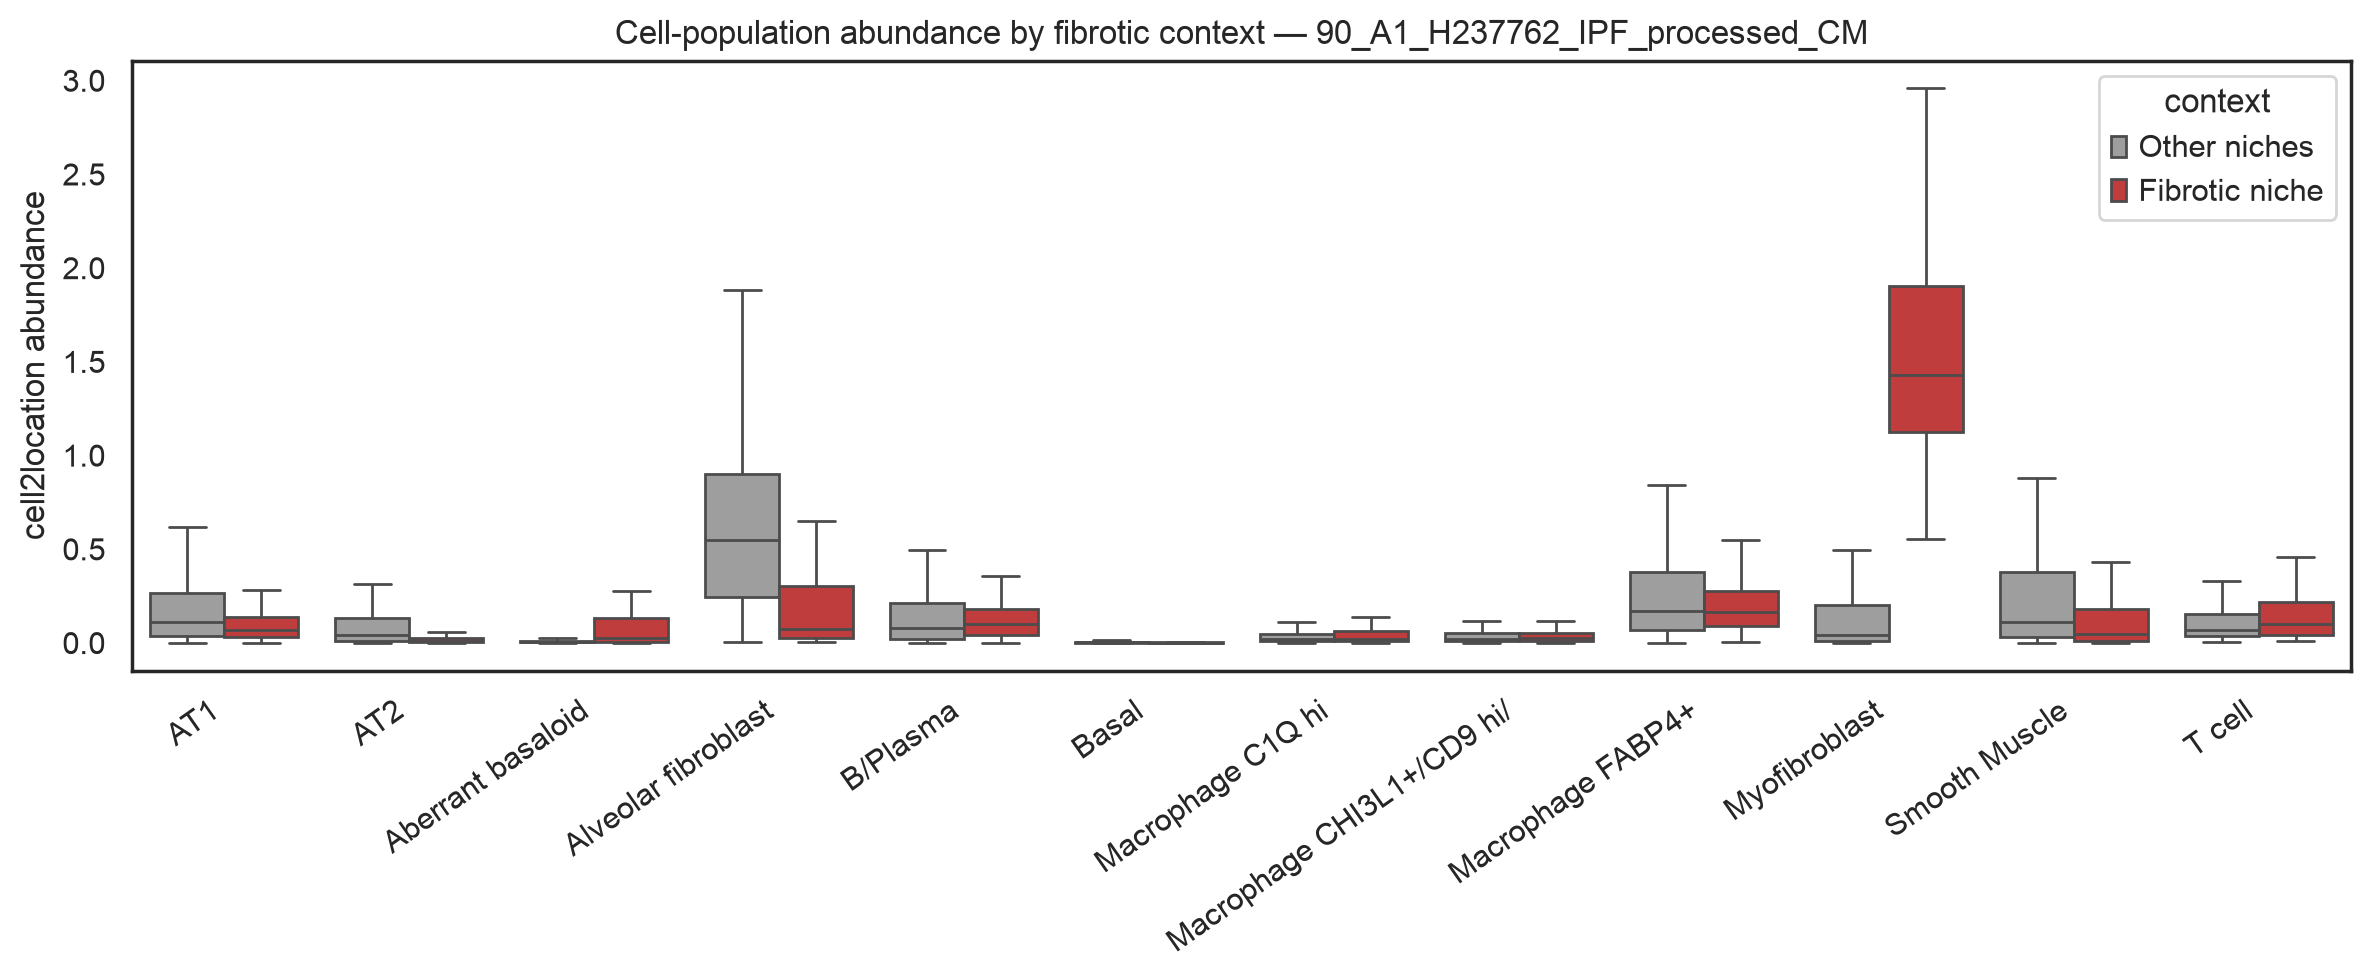

In [18]:
comparison = adata_sample.obs[representative_cell_types].copy()
comparison["context"] = np.where(
    adata_sample.obs["Niche_NMF"] == "Fibrotic",
    "Fibrotic niche",
    "Other niches",
)

comparison_long = comparison.melt(
    id_vars="context",
    var_name="cell population",
    value_name="cell2location abundance",
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=comparison_long,
    x="cell population",
    y="cell2location abundance",
    hue="context",
    showfliers=False,
    palette={"Fibrotic niche": "#D62728", "Other niches": "#9E9E9E"},
)
plt.xticks(rotation=35, ha="right")
plt.title(f"Cell-population abundance by fibrotic context — {sample}")
plt.xlabel("")
plt.tight_layout()

## Summary

- The processed object contains cell2location abundance estimates for 37 lung cell populations.
- NMF organizes these abundance profiles into eight spatially structured tissue niches.
- Niche-level enrichment profiles connect each discrete niche label to its characteristic multicellular composition.
- The fibrotic niche can be examined spatially together with representative stromal, epithelial, and macrophage populations.

The next notebook will construct Visium lattice-distance rings around fibrotic niche spots and evaluate spatial gradients in cells, genes, and pathway activity.